In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('../data/processed/dengue_features_final.csv')
df['month'] = pd.to_datetime(df['month'])

print(f"Data loaded: {df.shape}")
print(f"Date range: {df['month'].min()} to {df['month'].max()}")
df.head()

Data loaded: (129, 14)
Date range: 2012-04-01 00:00:00 to 2022-12-01 00:00:00


,month,cases,rainfall,temperature,year,month_num,quarter,cases_lag_1,cases_lag_2,cases_lag_3,cases_rolling_3,rainfall_lag_1,temp_lag_1,temp_rain_product
0,2012-04-01,363,260.6,24.8,2012,4,2,231.0,258.0,338.0,275.666667,313.4,24.4,7646.96
1,2012-05-01,338,292.0,24.8,2012,5,2,363.0,231.0,258.0,284.000000,260.6,24.8,6462.88
2,2012-06-01,468,53.0,26.3,2012,6,2,338.0,363.0,231.0,310.666667,292.0,24.8,7241.60
3,2012-07-01,601,130.8,25.3,2012,7,3,468.0,338.0,363.0,389.666667,53.0,26.3,1393.90
4,2012-08-01,436,119.0,25.4,2012,8,3,601.0,468.0,338.0,469.000000,130.8,25.3,3309.24


In [7]:
# Train-test split (80/20, time-series aware)
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index].copy()
test = df.iloc[split_index:].copy()

print(f"Training set: {len(train)} rows ({train['month'].min().date()} to {train['month'].max().date()})")
print(f"Test set: {len(test)} rows ({test['month'].min().date()} to {test['month'].max().date()})")

Training set: 103 rows (2012-04-01 to 2020-10-01)
Test set: 26 rows (2020-11-01 to 2022-12-01)


In [8]:
# Baseline: Naive forecast (next month = this month)
test['baseline_pred'] = test['cases'].shift(1)
test_baseline = test.dropna()

y_true = test_baseline['cases']
y_pred = test_baseline['baseline_pred']

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("BASELINE MODEL PERFORMANCE")
print("="*50)
print(f"MAE:  {mae:.2f} cases")
print(f"RMSE: {rmse:.2f} cases")
print(f"R²:   {r2:.3f}")

BASELINE MODEL PERFORMANCE
MAE:  534.88 cases
RMSE: 900.44 cases
R²:   0.705


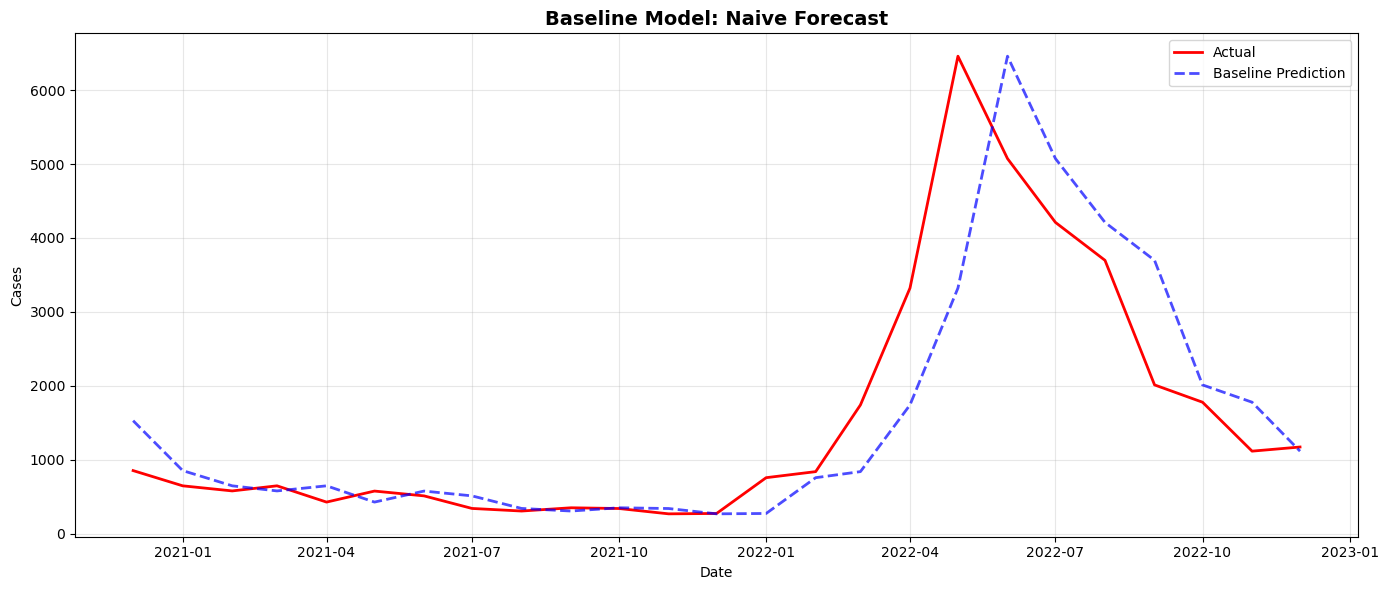

Saved: images/baseline_predictions.png


In [9]:
# Visualize baseline predictions
plt.figure(figsize=(14, 6))
plt.plot(test_baseline['month'], y_true, label='Actual', linewidth=2, color='red')
plt.plot(test_baseline['month'], y_pred, label='Baseline Prediction', 
         linestyle='--', linewidth=2, color='blue', alpha=0.7)
plt.title('Baseline Model: Naive Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../images/baseline_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: images/baseline_predictions.png")

In [10]:
# Save baseline results
baseline_results = {
    'model': 'Baseline (Naive Forecast)',
    'mae': mae,
    'rmse': rmse,
    'r2': r2
}

import json
with open('../data/processed/baseline_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=2)

print("Baseline results saved")
print(f"\nGoal for XGBoost: Beat MAE of {mae:.2f}")

Baseline results saved

Goal for XGBoost: Beat MAE of 534.88


#  Baseline Model 
## Model: Naive Forecast
Prediction: Next month cases = This month cases

## Performance:
- MAE:  534.88 cases
- RMSE: 900.44 cases
- R²:   0.705

